In [1]:
!pip install sdv

In [2]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='fake_hotel_guests'
)

In [3]:
real_data.head()

,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,michaelsanders@shaw.net,False,BASIC,37.89,27 Dec 2020,29 Dec 2020,131.23,"49380 Rivers Street\nSpencerville, AK 68265",4075084747483975747
1,randy49@brown.biz,False,BASIC,24.37,30 Dec 2020,02 Jan 2021,114.43,"88394 Boyle Meadows\nConleyberg, TN 22063",180072822063468
2,webermelissa@neal.com,True,DELUXE,0.00,17 Sep 2020,18 Sep 2020,368.33,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",38983476971380
3,gsims@terry.com,False,BASIC,NaN,28 Dec 2020,31 Dec 2020,115.61,"77 Massachusetts Ave\nCambridge, MA 02139",4969551998845740
4,misty33@smith.biz,False,BASIC,16.45,05 Apr 2020,NaN,122.41,"1234 Corporate Drive\nBoston, MA 02116",3558512986488983


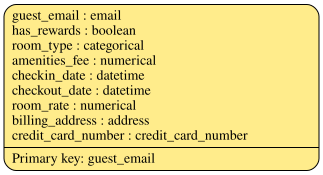

In [4]:
metadata.visualize()

In [15]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(
    metadata,     
    enforce_rounding=True,
    epochs=5000,
    verbose=True
)

In [16]:
synthesizer.fit(
    data=real_data
)

Gen. (-0.53) | Discrim. (-0.16): 100%|█████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:36<00:00, 137.37it/s]


In [17]:
synthetic_data = synthesizer.sample(
    num_rows=500
)

synthetic_data.head()

,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,dsullivan@example.net,False,BASIC,8.749778,2020-08-04,2020-08-05,105.474661,"90469 Karla Knolls Apt. 781\nSusanberg, CA 70033",5161033759518983
1,steven59@example.org,False,BASIC,5.463841,2020-06-10,2020-08-14,126.995424,"6108 Carla Ports Apt. 116\nPort Evan, MI 71694",4133047413145475690
2,brandon15@example.net,False,BASIC,27.836029,2020-07-24,2020-07-04,113.838221,86709 Jeremy Manors Apt. 786\nPort Garychester...,4977328103788
3,humphreyjennifer@example.net,False,BASIC,30.932273,2020-11-26,2020-11-27,99.528412,"8906 Bobby Trail\nEast Sandra, NY 43986",3524946844839485
4,joshuabrown@example.net,False,DELUXE,NaN,2020-03-08,2020-01-07,198.359614,"732 Dennis Lane\nPort Nicholasstad, DE 49786",4446905799576890978


In [18]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 4777.11it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2076.39it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [19]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 3291.37it/s]|
Column Shapes Score: 85.44%

(2/2) Evaluating Column Pair Trends: |████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 804.38it/s]|
Column Pair Trends Score: 82.45%

Overall Score (Average): 83.95%

